*Notebook erstellt von A. Naber, 20.6.2025*

## Magnetfeld eines Kreisstroms 

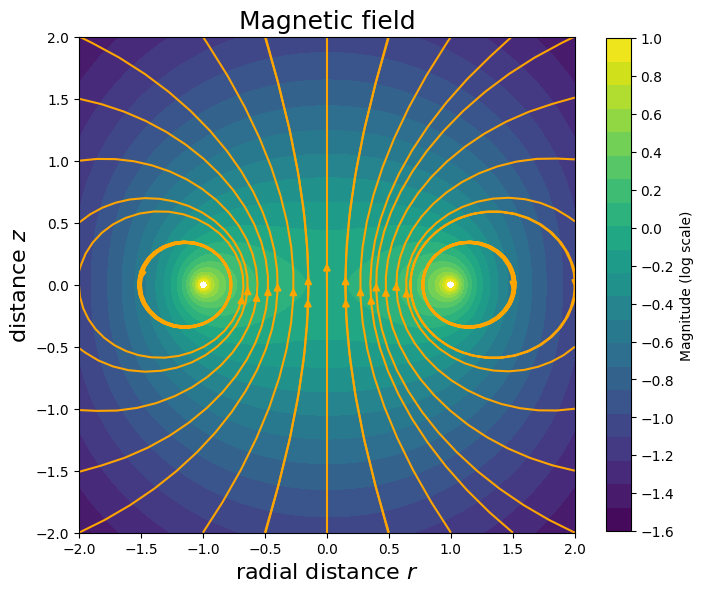

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk, ellipe    # complete elliptic integrals of 1st and 2nd kind

def k2(x,y):
    return 4*x*D/((D+x)**2+y**2)

def EE(x,y):
    return ellipe(k2(x,y))

def EK(x,y):
    return ellipk(k2(x,y))

def  Br(r,z):
    return z/(r*np.pi*np.sqrt((D+r)**2+z**2))*(-EK(r,z)+(D**2+r**2+z**2)/((D-r)**2+z**2)*EE(r,z))

def Bz(r,z):
    return 1/(np.pi*np.sqrt((D+r)**2+z**2))*(EK(r,z)+(D**2-r**2-z**2)/((D-r)**2+z**2)*EE(r,z))


D = 1            # radius of current loop

axmin = -2       # scale of plots 
axmax = +2
nMesh = 200      # size of mesh (for plots contourf an streamplot)
levmin = -1.6    # levels for contour plot and colorscale
levmax = 1.0 
nlevCol = 22     # number for colors
nlevNum = 14     # number for label
dens = 0.3       # density for stream plot 

r = np.linspace(axmin,axmax,nMesh) 
z = np.linspace(axmin,axmax,nMesh) 
R, Z = np.meshgrid(r, z)
lev = np.linspace(levmin,levmax, nlevCol)      # in log units

fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.axis('scaled')

plt.contourf(R, Z, np.log10(np.sqrt(Br(R,Z)**2+Bz(R,Z)**2)), levels=lev, cmap='viridis')
plt.colorbar(ticks=np.linspace(levmin,levmax,num=nlevNum),shrink=0.8,label='Magnitude (log scale)')
plt.streamplot(R,Z,Br(R,Z),Bz(R,Z),color='orange',density=dens,broken_streamlines=False)

plt.xticks(np.arange(axmin, axmax+0.1, 0.5))
plt.yticks(np.arange(axmin, axmax+0.1, 0.5))
plt.title('Magnetic field',fontsize=18)
plt.xlabel('radial distance $r$',fontsize=16)
plt.ylabel('distance $z$', fontsize=16)

plt.show()
